# Analyzing Privacy Policy Coverage and Data Safety Signals

This notebook checks whether each mHealth app has an accessible privacy policy file, identifies apps with missing or error privacy policies, merges Google Play Data Safety disclosures, and summarizes apps that lack privacy policy files but still declare data sharing or data collection practices.

## 1. Setup and helper functions

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Display options for cleaner notebook output
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Shared figure size applied to all plots in this notebook.
FIGSIZE = (4, 3)

# Paths
DATA_DIR = Path("../data")
POLICY_DIR = DATA_DIR / "privacy_policies"
ERROR_POLICY_DIR = DATA_DIR / "error_privacy_policy"

MHEALTH_APPS_PATH = DATA_DIR / "mhealth_apps_metrics.csv"
APP_DATA_SHARED_PATH = DATA_DIR / "app_data_shared.csv"
APP_DATA_COLLECTED_PATH = DATA_DIR / "app_data_collected.csv"
APP_SECURITY_PRACTICES_PATH = DATA_DIR / "app_security_practices.csv"
OUTPUT_PATH = DATA_DIR / "updated_mhealth_apps.csv"


def normalize_app_id(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip()


def ensure_unique_apps(df: pd.DataFrame, id_col: str = "app_id") -> pd.DataFrame:
    if df.empty:
        return df.copy()

    df = df.copy()
    df[id_col] = normalize_app_id(df[id_col])

    if "updated_on" in df.columns:
        df["_updated_on_sort"] = pd.to_datetime(
            df["updated_on"],
            format="%m/%d/%y",
            errors="coerce"
        )
        df["_non_null_count"] = df.notna().sum(axis=1)
        df = df.sort_values(
            by=[id_col, "_updated_on_sort", "_non_null_count"],
            ascending=[True, False, False],
        )
        df = df.drop(columns=["_updated_on_sort", "_non_null_count"])
    else:
        df["_non_null_count"] = df.notna().sum(axis=1)
        df = df.sort_values(by=[id_col, "_non_null_count"], ascending=[True, False])
        df = df.drop(columns=["_non_null_count"])

    return df.drop_duplicates(subset=id_col, keep="first").reset_index(drop=True)


def file_stems(directory: Path, suffix: str = ".txt") -> set[str]:
    if not directory.exists():
        print(f"Warning: directory does not exist: {directory}")
        return set()

    return {
        path.stem.strip()
        for path in directory.iterdir()
        if path.is_file() and not path.name.startswith(".") and (suffix is None or path.suffix == suffix)
    }


def has_nonempty_text(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip().ne("")


def join_nonempty(values: pd.Series) -> str:
    cleaned = values.dropna().astype(str).str.strip()
    cleaned = cleaned[cleaned.ne("")]
    unique_values = list(dict.fromkeys(cleaned.tolist()))
    return ",".join(unique_values)


def aggregate_by_app(df: pd.DataFrame, value_col: str) -> pd.Series:
    if df.empty or "app_id" not in df.columns or value_col not in df.columns:
        return pd.Series(dtype="object")

    df = df.copy()
    df["app_id"] = normalize_app_id(df["app_id"])

    return df.groupby("app_id", sort=False)[value_col].apply(join_nonempty)


def summarize_apps(df: pd.DataFrame, title: str, categories=("Health & Fitness", "Medical")) -> None:
    df = ensure_unique_apps(df)

    print(f"\n{'=' * 72}")
    print(title)
    print(f"{'=' * 72}")

    print(f"Apps: {df['app_id'].nunique():,}")
    print(f"Avg downloads: {df['downloads'].mean():,.2f}")
    print(f"Max downloads: {df['downloads'].max():,.2f}")

    print("\nTop categories:")
    display(df["categories"].value_counts().rename_axis("Category").reset_index(name="Apps").head(10))

    category_rows = []
    for category in categories:
        subset = df[df["categories"].eq(category)]
        category_rows.append({
            "Category": category,
            "Apps": subset["app_id"].nunique(),
            "Avg Downloads": round(subset["downloads"].mean(), 2),
        })

    print("\nFocused category averages:")
    display(pd.DataFrame(category_rows))


def plot_category_distribution(df: pd.DataFrame, title: str, figsize=FIGSIZE) -> None:
    df = ensure_unique_apps(df)
    counts = df["categories"].value_counts()

    if counts.empty:
        print(f"No rows available for: {title}")
        return

    ax = counts.plot(kind="bar", figsize=figsize)
    ax.set_ylabel("Number of Apps")
    ax.set_xlabel("Category")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


## 2. Load the mHealth app dataset

In [2]:
mhealth_apps_raw = pd.read_csv(MHEALTH_APPS_PATH)
mhealth_apps_raw["app_id"] = normalize_app_id(mhealth_apps_raw["app_id"])

raw_rows = len(mhealth_apps_raw)
raw_unique_apps = mhealth_apps_raw["app_id"].nunique()

mhealth_apps = ensure_unique_apps(mhealth_apps_raw)

for column in [
    "privacy_policy_file",
    "data_safety_data_shared",
    "data_safety_shared_purpose",
    "data_safety_data_collected",
    "data_safety_collected_purpose",
    "data_safety_security_practices",
]:
    if column not in mhealth_apps.columns:
        mhealth_apps[column] = ""

# Normalize fields used for filtering and summaries.
mhealth_apps["downloads"] = pd.to_numeric(mhealth_apps.get("downloads"), errors="coerce")
mhealth_apps["categories"] = mhealth_apps["categories"].fillna("Unknown").astype(str).str.strip()

mhealth_app_ids = set(mhealth_apps["app_id"].unique())

print(f"Raw rows loaded: {raw_rows:,}")
print(f"Raw unique apps: {raw_unique_apps:,}")
print(f"App-level rows after de-duplication: {len(mhealth_apps):,}")
print(f"Duplicate rows removed: {raw_rows - len(mhealth_apps):,}")

assert len(mhealth_apps) == mhealth_apps["app_id"].nunique(), "mhealth_apps still contains duplicate app_id rows."


/var/folders/1q/3rt9l52n0kx8ddr5w0rszmvr0000gn/T/ipykernel_21380/1536597220.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  mhealth_apps_raw = pd.read_csv(MHEALTH_APPS_PATH)


Raw rows loaded: 23,392
Raw unique apps: 931
App-level rows after de-duplication: 931
Duplicate rows removed: 22,461


## 3. Measure privacy policy file coverage

In [3]:
policy_files = file_stems(POLICY_DIR, suffix=".txt")

covered_apps = mhealth_app_ids.intersection(policy_files)
missing_apps = mhealth_app_ids - policy_files

total_apps = len(mhealth_app_ids)
covered_count = len(covered_apps)
missing_count = len(missing_apps)

mhealth_apps["privacy_policy_file"] = mhealth_apps["app_id"].apply(
    lambda app_id: "Yes" if app_id in policy_files else "No"
)

coverage_summary = pd.DataFrame([
    {"Policy File Status": "Available", "Apps": covered_count, "Share (%)": covered_count / total_apps * 100},
    {"Policy File Status": "Missing", "Apps": missing_count, "Share (%)": missing_count / total_apps * 100},
])
coverage_summary["Share (%)"] = coverage_summary["Share (%)"].round(2)

display(coverage_summary)


,Policy File Status,Apps,Share (%)
0,Available,780,83.78
1,Missing,151,16.22


## 4. Identify error privacy policy files

Some apps may have developer-declared privacy policy links but produce error files during collection. This cell treats those cases as part of the broader unavailable-policy group and reports how many apps are affected.


In [4]:
error_policy_files = file_stems(ERROR_POLICY_DIR, suffix=None)
error_policy_apps = error_policy_files.intersection(mhealth_app_ids)

apps_with_errors = ensure_unique_apps(mhealth_apps[mhealth_apps["app_id"].isin(error_policy_apps)])
apps_missing_policy_file = ensure_unique_apps(mhealth_apps[mhealth_apps["privacy_policy_file"].eq("No")])

# Combined unavailable-policy group: missing local policy file or collected error file.
apps_no_policy = ensure_unique_apps(
    pd.concat([apps_missing_policy_file, apps_with_errors], ignore_index=True)
)

print(f"Apps with error policy files: {apps_with_errors['app_id'].nunique():,}")
print(
    f"Apps with unavailable policy files: {apps_no_policy['app_id'].nunique():,} "
    f"({apps_no_policy['app_id'].nunique() / total_apps * 100:.2f}%)"
)

if not apps_with_errors.empty:
    display(
        apps_with_errors["categories"]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Apps with Error Policy File")
    )

if not apps_no_policy.empty:
    display(
        apps_no_policy["categories"]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Apps with Unavailable Policy File")
    )
    
if "is_privacy_policy" in mhealth_apps.columns:
    declared_policy_but_no_file = mhealth_apps[
        mhealth_apps["privacy_policy_file"].eq("No")
        & mhealth_apps["is_privacy_policy"].astype(str).str.strip().eq("Yes")
    ]["app_id"].nunique()

    print(f"Apps that declare a privacy policy but have no local policy file: {declared_policy_but_no_file:,}")

assert len(apps_no_policy) == apps_no_policy["app_id"].nunique(), "apps_no_policy contains duplicate app_id rows."


Apps with error policy files: 4
Apps with unavailable policy files: 155 (16.65%)


,Category,Apps with Error Policy File
0,Health & Fitness,4


,Category,Apps with Unavailable Policy File
0,Health & Fitness,93
1,Medical,36
2,Education,10
3,Lifestyle,10
4,Productivity,3
5,Food & Drink,2
6,Parenting,1


Apps that declare a privacy policy but have no local policy file: 151


### 5. Merge Google Play Data Safety disclosures

In [5]:
app_data_shared = pd.read_csv(APP_DATA_SHARED_PATH)
app_data_collected = pd.read_csv(APP_DATA_COLLECTED_PATH)
app_security_practices = pd.read_csv(APP_SECURITY_PRACTICES_PATH)

for df in [app_data_shared, app_data_collected, app_security_practices]:
    df["app_id"] = normalize_app_id(df["app_id"])

app_data_shared = app_data_shared[app_data_shared["app_id"].isin(mhealth_app_ids)].copy()
app_data_collected = app_data_collected[app_data_collected["app_id"].isin(mhealth_app_ids)].copy()
app_security_practices = app_security_practices[app_security_practices["app_id"].isin(mhealth_app_ids)].copy()

aggregated_fields = {
    "data_safety_data_shared": aggregate_by_app(app_data_shared, "data_safety_data_shared"),
    "data_safety_shared_purpose": aggregate_by_app(app_data_shared, "data_safety_shared_purpose"),
    "data_safety_data_collected": aggregate_by_app(app_data_collected, "data_safety_data_collected"),
    "data_safety_collected_purpose": aggregate_by_app(app_data_collected, "data_safety_collected_purpose"),
    "data_safety_security_practices": aggregate_by_app(app_security_practices, "data_safety_security_practices"),
}

for column, aggregated_series in aggregated_fields.items():
    mhealth_apps[column] = mhealth_apps["app_id"].map(aggregated_series).fillna("")

print("Merged Data Safety fields into unique app-level dataset.")
print(f"Rows in enriched mhealth_apps: {len(mhealth_apps):,}")
print(f"Unique app IDs in enriched mhealth_apps: {mhealth_apps['app_id'].nunique():,}")

assert len(mhealth_apps) == mhealth_apps["app_id"].nunique(), "Merge introduced duplicate app_id rows."


Merged Data Safety fields into unique app-level dataset.
Rows in enriched mhealth_apps: 931
Unique app IDs in enriched mhealth_apps: 931


## 6. Define no-policy apps with Data Safety signals

These cohorts focus on apps that lack an available privacy policy file but still report data sharing or data collection in Google Play Data Safety. They help identify transparency gaps between policy availability and platform-level disclosures.


In [6]:
apps_no_policy = apps_no_policy.merge(
    mhealth_apps[[
        "app_id",
        "data_safety_data_shared",
        "data_safety_shared_purpose",
        "data_safety_data_collected",
        "data_safety_collected_purpose",
        "data_safety_security_practices",
    ]],
    on="app_id",
    how="left",
    suffixes=("", "_updated"),
)

for column in ["data_safety_data_shared", "data_safety_shared_purpose", "data_safety_data_collected", "data_safety_collected_purpose", "data_safety_security_practices"]:
    updated_column = f"{column}_updated"
    if updated_column in apps_no_policy.columns:
        apps_no_policy[column] = apps_no_policy[updated_column].fillna(apps_no_policy[column])
        apps_no_policy = apps_no_policy.drop(columns=[updated_column])

apps_no_policy = ensure_unique_apps(apps_no_policy)
apps_no_policy["downloads"] = pd.to_numeric(apps_no_policy["downloads"], errors="coerce")

shared_mask = has_nonempty_text(apps_no_policy["data_safety_data_shared"])
collected_mask = has_nonempty_text(apps_no_policy["data_safety_data_collected"])

apps_no_policy_with_shared_data = ensure_unique_apps(apps_no_policy[shared_mask])
apps_no_policy_with_collected_data = ensure_unique_apps(apps_no_policy[collected_mask])
apps_no_policy_with_shared_and_collected_data = ensure_unique_apps(apps_no_policy[shared_mask & collected_mask])

summary = pd.DataFrame({
    "Group": ["Shared Only", "Collected Only", "Shared + Collected"],
    "Num Apps": [
        apps_no_policy_with_shared_data["app_id"].nunique(),
        apps_no_policy_with_collected_data["app_id"].nunique(),
        apps_no_policy_with_shared_and_collected_data["app_id"].nunique(),
    ],
    "Avg Downloads": [
        apps_no_policy_with_shared_data["downloads"].mean(),
        apps_no_policy_with_collected_data["downloads"].mean(),
        apps_no_policy_with_shared_and_collected_data["downloads"].mean(),
    ],
    "Max Downloads": [
        apps_no_policy_with_shared_data["downloads"].max(),
        apps_no_policy_with_collected_data["downloads"].max(),
        apps_no_policy_with_shared_and_collected_data["downloads"].max(),
    ],
})

summary[["Avg Downloads", "Max Downloads"]] = summary[["Avg Downloads", "Max Downloads"]].round(2)
display(summary)

for name, df in {
    "apps_no_policy": apps_no_policy,
    "apps_no_policy_with_shared_data": apps_no_policy_with_shared_data,
    "apps_no_policy_with_collected_data": apps_no_policy_with_collected_data,
    "apps_no_policy_with_shared_and_collected_data": apps_no_policy_with_shared_and_collected_data,
}.items():
    assert len(df) == df["app_id"].nunique(), f"{name} contains duplicate app_id rows."


,Group,Num Apps,Avg Downloads,Max Downloads
0,Shared Only,49,1823155.59,28044744
1,Collected Only,7,2116881.14,7514371
2,Shared + Collected,6,2414129.17,7514371


## 7. Visualize no-policy Data Safety cohorts

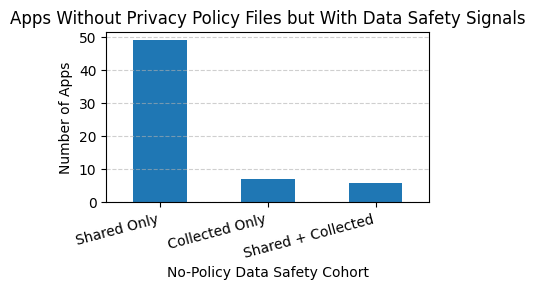

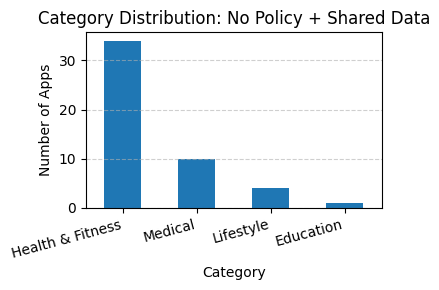

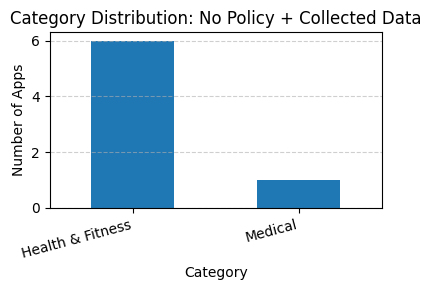

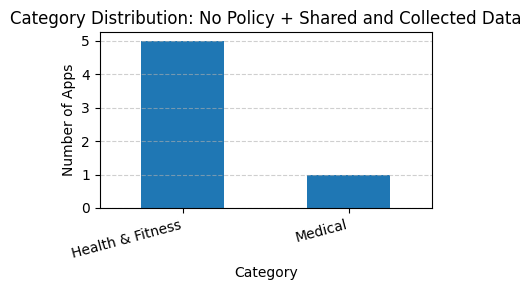

In [7]:
ax = summary.plot(
    kind="bar",
    x="Group",
    y="Num Apps",
    legend=False,
    figsize=FIGSIZE,
)
ax.set_ylabel("Number of Apps")
ax.set_xlabel("No-Policy Data Safety Cohort")
ax.set_title("Apps Without Privacy Policy Files but With Data Safety Signals")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plot_category_distribution(
    apps_no_policy_with_shared_data,
    "Category Distribution: No Policy + Shared Data",
    figsize=FIGSIZE,
)

plot_category_distribution(
    apps_no_policy_with_collected_data,
    "Category Distribution: No Policy + Collected Data",
    figsize=FIGSIZE,
)

plot_category_distribution(
    apps_no_policy_with_shared_and_collected_data,
    "Category Distribution: No Policy + Shared and Collected Data",
    figsize=FIGSIZE,
)


## 8. Focused comparison between Health & Fitness and Medical apps

This table compares average downloads for two central mHealth-related categories. Each input cohort is de-duplicated by `app_id` before computing averages so duplicate rows do not bias the comparison.


In [8]:
def category_average_downloads(df: pd.DataFrame, category: str) -> float:
    df = ensure_unique_apps(df)
    return round(df.loc[df["categories"].eq(category), "downloads"].mean(), 2)

comparison = pd.DataFrame({
    "Category": ["Health & Fitness", "Medical"],
    "Avg Downloads: No Policy + Collected": [
        category_average_downloads(apps_no_policy_with_collected_data, "Health & Fitness"),
        category_average_downloads(apps_no_policy_with_collected_data, "Medical"),
    ],
    "Avg Downloads: No Policy + Shared and Collected": [
        category_average_downloads(apps_no_policy_with_shared_and_collected_data, "Health & Fitness"),
        category_average_downloads(apps_no_policy_with_shared_and_collected_data, "Medical"),
    ],
})

display(comparison)


,Category,Avg Downloads: No Policy + Collected,Avg Downloads: No Policy + Shared and Collected
0,Health & Fitness,2408524.0,2823550.2
1,Medical,367024.0,367024.0


## 9. Compact cohort reports

The final reporting cell prints consistent summaries for each no-policy cohort. The helper function internally enforces unique `app_id` rows before computing counts, category distributions, and download averages.


In [9]:
summarize_apps(apps_no_policy_with_shared_data, "No Policy + Shared Data")
summarize_apps(apps_no_policy_with_collected_data, "No Policy + Collected Data")
summarize_apps(apps_no_policy_with_shared_and_collected_data, "No Policy + Shared and Collected Data")



No Policy + Shared Data
Apps: 49
Avg downloads: 1,823,155.59
Max downloads: 28,044,744.00

Top categories:


,Category,Apps
0,Health & Fitness,34
1,Medical,10
2,Lifestyle,4
3,Education,1



Focused category averages:


,Category,Apps,Avg Downloads
0,Health & Fitness,34,2198383.85
1,Medical,10,1306635.90



No Policy + Collected Data
Apps: 7
Avg downloads: 2,116,881.14
Max downloads: 7,514,371.00

Top categories:


...

,Category,Apps,Avg Downloads
0,Health & Fitness,6,2408524.0
1,Medical,1,367024.0



No Policy + Shared and Collected Data
Apps: 6
Avg downloads: 2,414,129.17
Max downloads: 7,514,371.00

Top categories:


,Category,Apps
0,Health & Fitness,5
1,Medical,1



Focused category averages:


,Category,Apps,Avg Downloads
0,Health & Fitness,5,2823550.2
1,Medical,1,367024.0
